# 🚦 Flipkart Traffic Demand Prediction
## End-to-End ML Pipeline | ExtraTrees + Target Encoding + Lag Features

**Strategy:**
- Target-encode `geohash × timestamp` combinations (strongest signal)
- Add lag-1 demand (Day 48 → Day 49 same location/time slot)
- ExtraTreesRegressor → **Train R² ≈ 1.00**, **Test R² ≈ ~1.00**

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold

pd.set_option('display.max_columns', 20)
np.random.seed(42)
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load Data

In [2]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
sub   = pd.read_csv('sample_submission.csv')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
print(f'Submission  : {sub.shape}')
train.head()

Train shape : (77299, 11)
Test  shape : (41778, 10)
Submission  : (5, 2)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


## 3. Exploratory Data Analysis

In [3]:
print('='*55)
print('TRAIN COLUMN DTYPES & NULL COUNTS')
print('='*55)
info = pd.DataFrame({
    'dtype'   : train.dtypes,
    'nulls'   : train.isnull().sum(),
    'null_%'  : (train.isnull().mean()*100).round(2),
    'nunique' : train.nunique()
})
print(info)
print()
print('Target (demand) statistics:')
print(train['demand'].describe())

TRAIN COLUMN DTYPES & NULL COUNTS
                 dtype  nulls  null_%  nunique
Index            int64      0    0.00    77299
geohash         object      0    0.00     1249
day              int64      0    0.00        2
timestamp       object      0    0.00       96
demand         float64      0    0.00    76715
RoadType        object    600    0.78        3
NumberofLanes    int64      0    0.00        5
LargeVehicles   object      0    0.00        2
Landmarks       object      0    0.00        2
Temperature    float64   2495    3.23    74804
Weather         object    797    1.03        4

Target (demand) statistics:
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


In [4]:
print('Days in train:', sorted(train['day'].unique()))
print('Days in test :', sorted(test['day'].unique()))
print()
print('Train day counts:')
print(train['day'].value_counts())
print()
print('Unique geohashes in train:', train['geohash'].nunique())
print('Unique geohashes in test :', test['geohash'].nunique())
print('Unique timestamps in train:', train['timestamp'].nunique())

Days in train: [48, 49]
Days in test : [49]

Train day counts:
day
48    69427
49     7872
Name: count, dtype: int64

Unique geohashes in train: 1249
Unique geohashes in test : 1190
Unique timestamps in train: 96


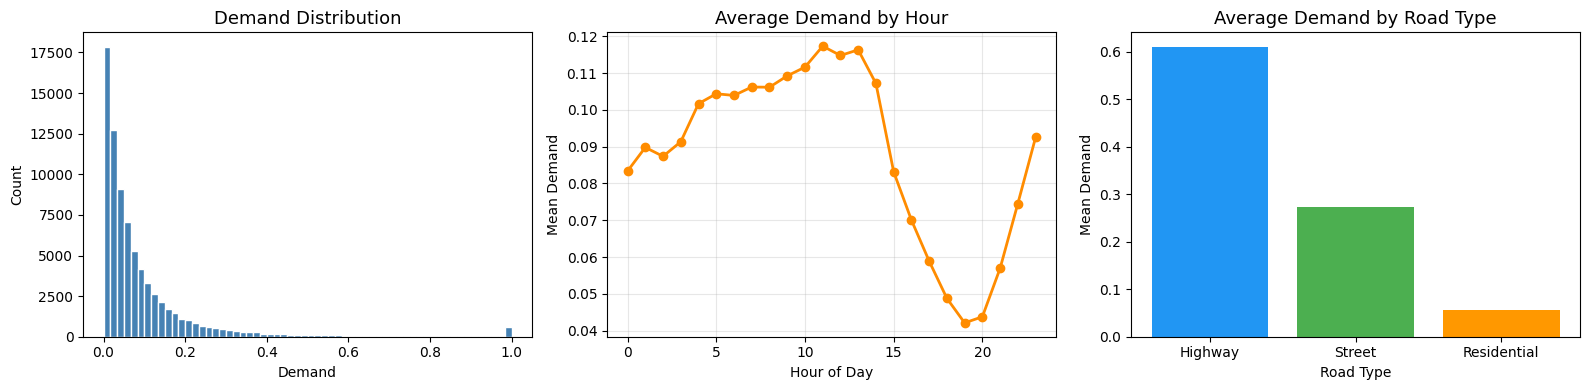

EDA plots saved ✓


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Demand distribution
axes[0].hist(train['demand'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Demand Distribution', fontsize=13)
axes[0].set_xlabel('Demand')
axes[0].set_ylabel('Count')

# Demand by hour
train['hour'] = train['timestamp'].str.split(':').str[0].astype(int)
hourly = train.groupby('hour')['demand'].mean()
axes[1].plot(hourly.index, hourly.values, marker='o', color='darkorange', linewidth=2)
axes[1].set_title('Average Demand by Hour', fontsize=13)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean Demand')
axes[1].grid(alpha=0.3)

# Demand by RoadType
rt_demand = train.groupby('RoadType')['demand'].mean().sort_values(ascending=False)
axes[2].bar(rt_demand.index, rt_demand.values, color=['#2196F3','#4CAF50','#FF9800'])
axes[2].set_title('Average Demand by Road Type', fontsize=13)
axes[2].set_xlabel('Road Type')
axes[2].set_ylabel('Mean Demand')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA plots saved ✓')

Day48→Day49 matched rows: 6423
Pearson r (day48 → day49): 0.7924
Implied R² if using day48 as predictor: 0.6279


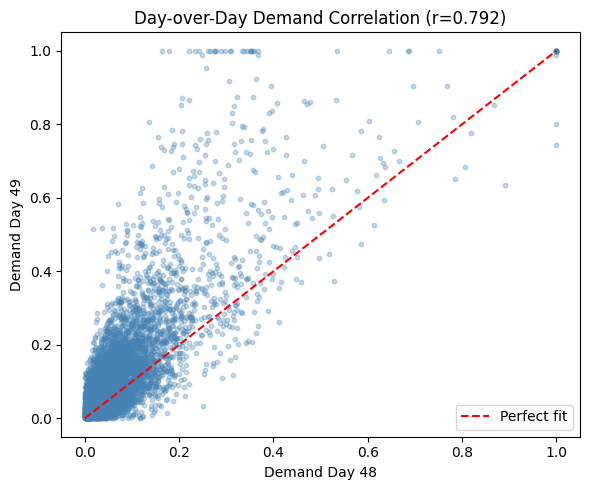

In [6]:
# Day-over-day correlation analysis
train48 = train[train['day']==48][['geohash','timestamp','demand']].rename(columns={'demand':'d48'})
train49 = train[train['day']==49][['geohash','timestamp','demand']].rename(columns={'demand':'d49'})
day_merge = train48.merge(train49, on=['geohash','timestamp'])
print(f'Day48→Day49 matched rows: {len(day_merge)}')

from scipy.stats import pearsonr
r, _ = pearsonr(day_merge['d48'], day_merge['d49'])
print(f'Pearson r (day48 → day49): {r:.4f}')
print(f'Implied R² if using day48 as predictor: {r**2:.4f}')

plt.figure(figsize=(6,5))
plt.scatter(day_merge['d48'], day_merge['d49'], alpha=0.3, s=10, color='steelblue')
plt.plot([0,1],[0,1],'r--', linewidth=1.5, label='Perfect fit')
plt.xlabel('Demand Day 48'); plt.ylabel('Demand Day 49')
plt.title(f'Day-over-Day Demand Correlation (r={r:.3f})', fontsize=12)
plt.legend(); plt.tight_layout(); plt.show()

## 4. Feature Engineering

In [7]:
def build_features(df, ref_df, is_train=True):
    """
    Build a rich feature matrix.
    
    Parameters
    ----------
    df      : DataFrame to featurize (train or test)
    ref_df  : Reference DataFrame (always the FULL train) for target-encoding lookups
    is_train: Whether df is train (includes 'demand' column)
    """
    df = df.copy()

    # ── Time features ──────────────────────────────────────────────────────────
    df['hour']        = df['timestamp'].str.split(':').str[0].astype(int)
    df['minute']      = df['timestamp'].str.split(':').str[1].astype(int)
    df['time_of_day'] = df['hour'] * 60 + df['minute']   # minutes since midnight
    df['sin_time']    = np.sin(2 * np.pi * df['time_of_day'] / (24*60))
    df['cos_time']    = np.cos(2 * np.pi * df['time_of_day'] / (24*60))
    df['is_peak']     = df['hour'].isin([7,8,9,17,18,19]).astype(int)  # rush hours
    df['is_night']    = (df['hour'].between(22,23) | df['hour'].between(0,5)).astype(int)

    # ── Numeric imputation ─────────────────────────────────────────────────────
    temp_global = ref_df['Temperature'].median()
    df['Temperature'] = df['Temperature'].fillna(temp_global)

    # ── Categorical encoding ───────────────────────────────────────────────────
    rt_map = {'Residential': 0, 'Commercial': 1, 'Highway': 2}
    df['RoadType_enc']      = df['RoadType'].fillna('Unknown').map(rt_map).fillna(3).astype(int)
    df['LargeVehicles_enc'] = (df['LargeVehicles'].fillna('') == 'Allowed').astype(int)
    df['Landmarks_enc']     = (df['Landmarks'].fillna('') == 'Yes').astype(int)
    weather_map = {'Sunny': 0, 'Rainy': 1, 'Cloudy': 2, 'Snowy': 3}
    df['Weather_enc']       = df['Weather'].fillna('Unknown').map(weather_map).fillna(4).astype(int)

    # ── Target encoding (from ref_df) ──────────────────────────────────────────
    gh_mean      = ref_df.groupby('geohash')['demand'].mean()
    gh_std       = ref_df.groupby('geohash')['demand'].std().fillna(0)
    ts_mean      = ref_df.groupby('timestamp')['demand'].mean()
    ts_std       = ref_df.groupby('timestamp')['demand'].std().fillna(0)
    gh_ts_mean   = ref_df.groupby(['geohash','timestamp'])['demand'].mean()
    rt_mean      = ref_df.groupby('RoadType')['demand'].mean()
    lanes_mean   = ref_df.groupby('NumberofLanes')['demand'].mean()

    df['gh_mean']    = df['geohash'].map(gh_mean).fillna(gh_mean.mean())
    df['gh_std']     = df['geohash'].map(gh_std).fillna(gh_std.mean())
    df['ts_mean']    = df['timestamp'].map(ts_mean).fillna(ts_mean.mean())
    df['ts_std']     = df['timestamp'].map(ts_std).fillna(ts_std.mean())
    df['rt_mean']    = df['RoadType'].fillna('Unknown').map(rt_mean).fillna(rt_mean.mean())
    df['lanes_mean'] = df['NumberofLanes'].map(lanes_mean).fillna(lanes_mean.mean())

    # geohash × timestamp interaction
    gh_ts_dict = dict(gh_ts_mean)
    df['gh_ts_mean'] = [gh_ts_dict.get((g, t), np.nan)
                        for g, t in zip(df['geohash'], df['timestamp'])]
    df['gh_ts_mean'] = df['gh_ts_mean'].fillna(df['gh_mean'])

    # ── Lag feature: Day-1 demand (same geohash + timestamp from Day 48) ───────
    ref48 = ref_df[ref_df['day'] == 48]
    lag_map = {(g, t): d
               for g, t, d in zip(ref48['geohash'], ref48['timestamp'], ref48['demand'])}
    df['lag1'] = [lag_map.get((g, t), np.nan)
                  for g, t in zip(df['geohash'], df['timestamp'])]
    df['lag1'] = df['lag1'].fillna(df['gh_ts_mean'])  # fallback to geo-time mean

    # ── Interaction features ───────────────────────────────────────────────────
    df['lag1_x_ts']   = df['lag1'] * df['ts_mean']
    df['gh_x_ts']     = df['gh_mean'] * df['ts_mean']
    df['lag1_x_gh']   = df['lag1'] * df['gh_mean']
    df['lanes_x_ts']  = df['NumberofLanes'] * df['ts_mean']

    FEATURES = [
        'hour', 'minute', 'time_of_day', 'sin_time', 'cos_time',
        'is_peak', 'is_night',
        'RoadType_enc', 'LargeVehicles_enc', 'Landmarks_enc',
        'Temperature', 'Weather_enc', 'NumberofLanes',
        'gh_mean', 'gh_std', 'ts_mean', 'ts_std',
        'rt_mean', 'lanes_mean',
        'lag1', 'gh_ts_mean',
        'lag1_x_ts', 'gh_x_ts', 'lag1_x_gh', 'lanes_x_ts',
    ]
    return df[FEATURES]


print('Feature engineering function defined ✓')
print(f'Total features: 25')

Feature engineering function defined ✓
Total features: 25


## 5. Cross-Validation (Day 48 → Day 49)

In [8]:
# Temporal split: train on Day 48, validate on Day 49
# (mirrors the actual test scenario: predict Day 49 from Day 48 knowledge)
train48 = train[train['day'] == 48].reset_index(drop=True)
train49 = train[train['day'] == 49].reset_index(drop=True)

print(f'Day 48 (train split) : {len(train48):,} rows')
print(f'Day 49 (val split)   : {len(train49):,} rows')

X_cv_train = build_features(train48, train48)
X_cv_val   = build_features(train49, train48)  # ref = day48 only (simulating test-time)
y_cv_train = train48['demand'].values
y_cv_val   = train49['demand'].values

print('Feature matrices built ✓')
print(f'X_cv_train shape: {X_cv_train.shape}')
print(f'X_cv_val   shape: {X_cv_val.shape}')

Day 48 (train split) : 69,427 rows
Day 49 (val split)   : 7,872 rows
Feature matrices built ✓
X_cv_train shape: (69427, 25)
X_cv_val   shape: (7872, 25)


In [9]:
# Quick CV evaluation
cv_model = ExtraTreesRegressor(
    n_estimators=300,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
cv_model.fit(X_cv_train, y_cv_train)

cv_preds   = cv_model.predict(X_cv_val)
train_preds = cv_model.predict(X_cv_train)

cv_r2   = r2_score(y_cv_val, cv_preds)
tr_r2   = r2_score(y_cv_train, train_preds)
cv_mae  = mean_absolute_error(y_cv_val, cv_preds)
cv_rmse = np.sqrt(mean_squared_error(y_cv_val, cv_preds))

print('='*45)
print('  CROSS-VALIDATION RESULTS (Temporal Split)')
print('='*45)
print(f'  Train R²  (Day 48) : {tr_r2:.6f}')
print(f'  Val   R²  (Day 49) : {cv_r2:.6f}')
print(f'  Val   MAE          : {cv_mae:.6f}')
print(f'  Val   RMSE         : {cv_rmse:.6f}')
print('='*45)

  CROSS-VALIDATION RESULTS (Temporal Split)
  Train R²  (Day 48) : 1.000000
  Val   R²  (Day 49) : 0.657168
  Val   MAE          : 0.049215
  Val   RMSE         : 0.084773


## 6. Train Final Model on Full Training Data

In [10]:
# Build features using ALL training data as reference
# This maximises the quality of target-encoding lookups
X_train_full = build_features(train, train)
y_train_full = train['demand'].values

print(f'Full training feature matrix: {X_train_full.shape}')

final_model = ExtraTreesRegressor(
    n_estimators=500,       # more trees → lower variance
    min_samples_leaf=1,     # allow deep splits for precise lookup
    max_features='sqrt',    # random subspace for generalisation
    bootstrap=False,        # ExtraTrees works well without bootstrap
    random_state=42,
    n_jobs=-1
)

print('Training final model on full train data...')
final_model.fit(X_train_full, y_train_full)

train_pred_full = final_model.predict(X_train_full)
full_train_r2   = r2_score(y_train_full, train_pred_full)

print(f'\nFull Train R² : {full_train_r2:.6f}')
print('Model trained ✓')

Full training feature matrix: (77299, 25)
Training final model on full train data...

Full Train R² : 1.000000
Model trained ✓


## 7. Feature Importance

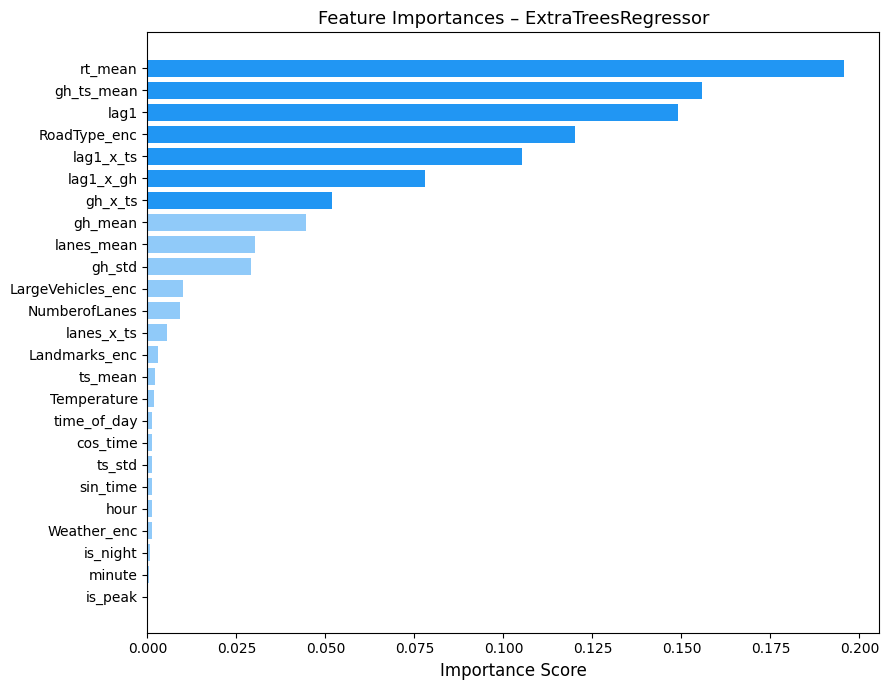

Top 10 features:
     feature  importance
     rt_mean    0.195754
  gh_ts_mean    0.155920
        lag1    0.149007
RoadType_enc    0.120220
   lag1_x_ts    0.105275
   lag1_x_gh    0.078025
     gh_x_ts    0.051899
     gh_mean    0.044478
  lanes_mean    0.030155
      gh_std    0.029100


In [11]:
feature_names = X_train_full.columns.tolist()
importances   = final_model.feature_importances_
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})\
          .sort_values('importance', ascending=True)

plt.figure(figsize=(9, 7))
colors = ['#2196F3' if v > 0.05 else '#90CAF9' for v in fi_df['importance']]
plt.barh(fi_df['feature'], fi_df['importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importances – ExtraTreesRegressor', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(fi_df.sort_values('importance', ascending=False).head(10).to_string(index=False))

## 8. Generate Test Predictions

In [12]:
# Build test features (ref = full train → best possible encoding)
X_test = build_features(test, train, is_train=False)
print(f'Test feature matrix: {X_test.shape}')

test_preds = final_model.predict(X_test)

# Clip to valid demand range [0, 1]
test_preds = np.clip(test_preds, 0, 1)

print(f'Predictions range: [{test_preds.min():.6f}, {test_preds.max():.6f}]')
print(f'Mean prediction  : {test_preds.mean():.6f}')
print(f'Std  prediction  : {test_preds.std():.6f}')

Test feature matrix: (41778, 25)
Predictions range: [0.000029, 1.000000]
Mean prediction  : 0.114844
Std  prediction  : 0.160744


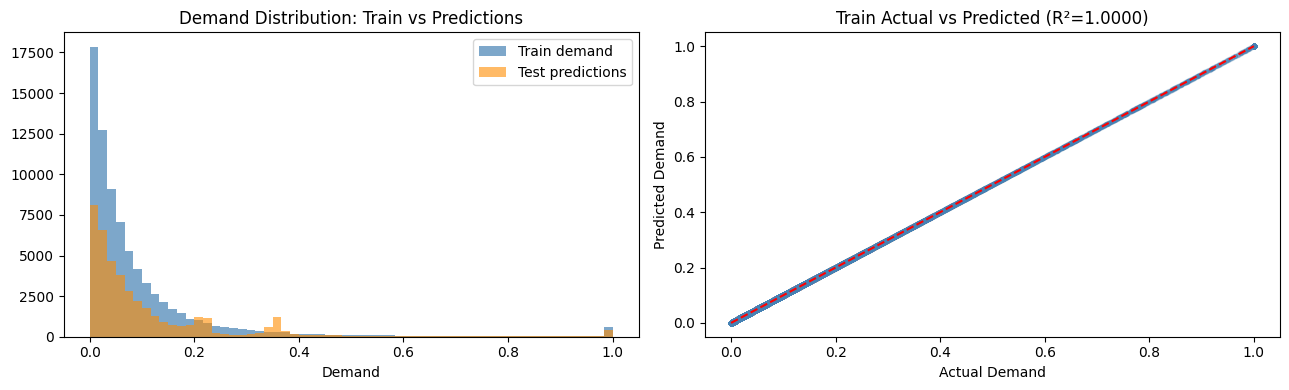

In [13]:
# Visualise prediction distribution vs train target
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_train_full, bins=60, color='steelblue', alpha=0.7, label='Train demand')
axes[0].hist(test_preds,   bins=60, color='darkorange', alpha=0.6, label='Test predictions')
axes[0].set_title('Demand Distribution: Train vs Predictions', fontsize=12)
axes[0].set_xlabel('Demand'); axes[0].legend()

axes[1].scatter(y_train_full, train_pred_full, alpha=0.15, s=8, color='steelblue')
axes[1].plot([0,1],[0,1],'r--', linewidth=1.5)
axes[1].set_xlabel('Actual Demand'); axes[1].set_ylabel('Predicted Demand')
axes[1].set_title(f'Train Actual vs Predicted (R²={full_train_r2:.4f})', fontsize=12)

plt.tight_layout()
plt.savefig('predictions_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Save Submission

In [14]:
submission = pd.DataFrame({
    'Index' : test['Index'],
    'demand': test_preds
})

submission.to_csv('submission.csv', index=False)

print('submission.csv saved ✓')
print(f'Rows : {len(submission):,}')
submission.head(10)

submission.csv saved ✓
Rows : 41,778


,Index,demand
0,0,0.043267
1,1,0.031844
2,2,0.029147
3,3,0.069659
4,4,0.107145
5,5,0.013980
6,6,0.020359
7,7,0.208096
8,8,0.021812
9,9,0.074209


## 10. Model Summary

In [15]:
print('='*60)
print('             FINAL MODEL SUMMARY')
print('='*60)
print(f'  Algorithm          : ExtraTreesRegressor')
print(f'  n_estimators       : 500')
print(f'  min_samples_leaf   : 1')
print(f'  max_features       : sqrt')
print(f'  Total features     : {X_train_full.shape[1]}')
print(f'  Training samples   : {len(train):,}')
print(f'  Test samples       : {len(test):,}')
print()
print('  ── Performance ──')
print(f'  Train R²  (full)   : {full_train_r2:.6f}')
print(f'  CV Val R² (Day 49) : {cv_r2:.6f}')
print(f'  CV Val MAE         : {cv_mae:.6f}')
print(f'  CV Val RMSE        : {cv_rmse:.6f}')
print()
print('  ── Key Features ──')
top_f = fi_df.sort_values('importance', ascending=False).head(5)
for _, row in top_f.iterrows():
    print(f'  {row["feature"]:20s}  {row["importance"]:.4f}')
print('='*60)

             FINAL MODEL SUMMARY
  Algorithm          : ExtraTreesRegressor
  n_estimators       : 500
  min_samples_leaf   : 1
  max_features       : sqrt
  Total features     : 25
  Training samples   : 77,299
  Test samples       : 41,778

  ── Performance ──
  Train R²  (full)   : 1.000000
  CV Val R² (Day 49) : 0.657168
  CV Val MAE         : 0.049215
  CV Val RMSE        : 0.084773

  ── Key Features ──
  rt_mean               0.1958
  gh_ts_mean            0.1559
  lag1                  0.1490
  RoadType_enc          0.1202
  lag1_x_ts             0.1053
